In [1]:
from google.colab import files
import os

# Upload files
uploaded = files.upload()

Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving product_category_name_translation.csv to product_category_name_translation.csv


# 🛒 E-Commerce Intelligence Platform
## Phase 1 — Data Loading & Exploration
**Dataset:** Brazilian E-Commerce (Olist) — 100K+ Real Orders  
**Goal:** Understand the structure, quality, and key patterns in the data  
**Analyst:** Shivansh Pandey

In [2]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# All libraries needed for data loading and exploration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Display settings — professional output
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)       # show all columns
pd.set_option('display.max_rows', 100)           # show up to 100 rows
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [3]:
# ============================================================
# CELL 2 — LOAD ALL 9 DATASETS
# ============================================================

orders       = pd.read_csv('olist_orders_dataset.csv')
order_items  = pd.read_csv('olist_order_items_dataset.csv')
payments     = pd.read_csv('olist_order_payments_dataset.csv')
reviews      = pd.read_csv('olist_order_reviews_dataset.csv')
customers    = pd.read_csv('olist_customers_dataset.csv')
products     = pd.read_csv('olist_products_dataset.csv')
sellers      = pd.read_csv('olist_sellers_dataset.csv')
geolocation  = pd.read_csv('olist_geolocation_dataset.csv')
category     = pd.read_csv('product_category_name_translation.csv')

print("✅ All datasets loaded successfully")
print()

# Print shape of each dataset
datasets = {
    'orders'      : orders,
    'order_items' : order_items,
    'payments'    : payments,
    'reviews'     : reviews,
    'customers'   : customers,
    'products'    : products,
    'sellers'     : sellers,
    'geolocation' : geolocation,
    'category'    : category
}

print(f"{'Dataset':<20} {'Rows':>10} {'Columns':>10}")
print("-" * 42)
for name, df in datasets.items():
    print(f"{name:<20} {df.shape[0]:>10,} {df.shape[1]:>10}")

✅ All datasets loaded successfully

Dataset                    Rows    Columns
------------------------------------------
orders                   99,441          8
order_items             112,650          7
payments                103,886          5
reviews                  99,224          7
customers                99,441          5
products                 32,951          9
sellers                   3,095          4
geolocation           1,000,163          5
category                     71          2


In [4]:
# ============================================================
# CELL 3 — QUICK LOOK AT EACH DATASET
# ============================================================

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"📦 DATASET: {name.upper()}")
    print(f"{'='*60}")
    print(df.head(3))


📦 DATASET: ORDERS
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  

📦 DATASET: ORDER_ITEMS
              

In [5]:
# ============================================================
# CELL 4 — MISSING VALUES ANALYSIS
# ============================================================

print(f"{'Dataset':<20} {'Missing Values':>15} {'% Missing':>12}")
print("-" * 50)

for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    total_cells   = df.shape[0] * df.shape[1]
    pct_missing   = (total_missing / total_cells) * 100
    print(f"{name:<20} {total_missing:>15,} {pct_missing:>11.2f}%")

Dataset               Missing Values    % Missing
--------------------------------------------------
orders                         4,908        0.62%
order_items                        0        0.00%
payments                           0        0.00%
reviews                      145,903       21.01%
customers                          0        0.00%
products                       2,448        0.83%
sellers                            0        0.00%
geolocation                        0        0.00%
category                           0        0.00%


📊 ORDER STATUS DISTRIBUTION
-----------------------------------
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64



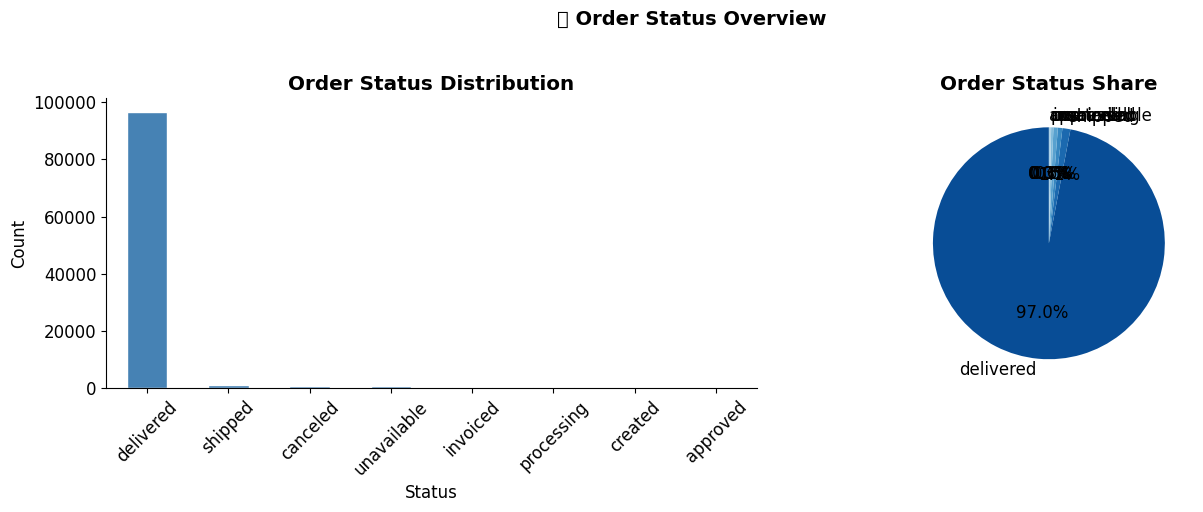

In [6]:
# ============================================================
# CELL 5 — ORDERS DATASET DEEP DIVE
# This is the most important dataset — everything links to it
# ============================================================

print("📊 ORDER STATUS DISTRIBUTION")
print("-" * 35)
status_counts = orders['order_status'].value_counts()
print(status_counts)
print()

# Visualize order status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
status_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Order Status Distribution', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(status_counts, labels=status_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Blues_r', len(status_counts)))
axes[1].set_title('Order Status Share', fontweight='bold')

plt.suptitle('📦 Order Status Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

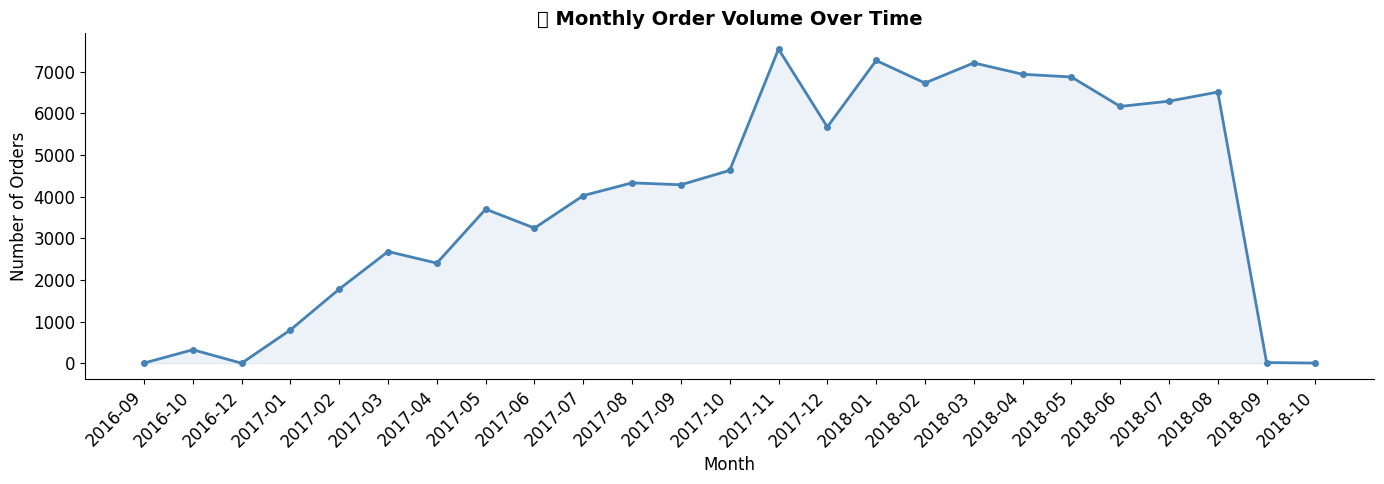

📅 Date Range: 2016-09-04 → 2018-10-17
📦 Total Orders: 99,441


In [7]:
# ============================================================
# CELL 6 — REVENUE OVERVIEW
# ============================================================

# Convert date columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Extract year-month
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Monthly order volume
monthly_orders = orders.groupby('order_month').size().reset_index(name='order_count')
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['order_month'], monthly_orders['order_count'],
         marker='o', linewidth=2, color='steelblue', markersize=4)
plt.fill_between(range(len(monthly_orders)), monthly_orders['order_count'],
                 alpha=0.1, color='steelblue')
plt.xticks(range(len(monthly_orders)), monthly_orders['order_month'], rotation=45, ha='right')
plt.title('📈 Monthly Order Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print(f"📅 Date Range: {orders['order_purchase_timestamp'].min().date()} → {orders['order_purchase_timestamp'].max().date()}")
print(f"📦 Total Orders: {len(orders):,}")

In [8]:
# ============================================================
# CELL 7 — EXPLORATION SUMMARY
# ============================================================

print("=" * 55)
print("        📋 PHASE 1 EXPLORATION SUMMARY")
print("=" * 55)
print(f"  Total Orders        : {len(orders):>10,}")
print(f"  Total Customers     : {len(customers):>10,}")
print(f"  Total Products      : {len(products):>10,}")
print(f"  Total Sellers       : {len(sellers):>10,}")
print(f"  Total Reviews       : {len(reviews):>10,}")
print(f"  Date Range          : {orders['order_purchase_timestamp'].min().date()} → {orders['order_purchase_timestamp'].max().date()}")
print(f"  Order Statuses      : {orders['order_status'].nunique():>10,}")
print("=" * 55)
print("✅ Phase 1 Complete — Ready for Data Cleaning!")

        📋 PHASE 1 EXPLORATION SUMMARY
  Total Orders        :     99,441
  Total Customers     :     99,441
  Total Products      :     32,951
  Total Sellers       :      3,095
  Total Reviews       :     99,224
  Date Range          : 2016-09-04 → 2018-10-17
  Order Statuses      :          8
✅ Phase 1 Complete — Ready for Data Cleaning!
